## The k-NN classifier

### 1. k-NN classifier using a toy dataset

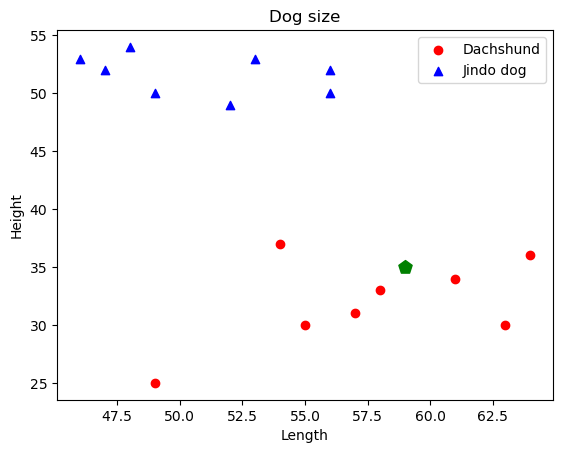

In [1]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 두 종류의 개, 닥스훈트(Dachshund)와 진돗개(Jindo dog)의 체형 데이터를 시각화하여,
# 길이(Length)와 높이(Height)라는 두 특성에 따라 구분 가능함을 확인하기 위한 시각화 실습임.
# matplotlib를 이용하여 두 종의 데이터를 산점도로 표시하고, 새로운 개 데이터를 동일한 축 위에 표시함.
# 시각적 군집 특성을 통해 이후 k-NN 기반 분류 학습 또는 직관적 판단의 기반으로 활용 가능함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: matplotlib 라이브러리 임포트 (시각화 기능 제공)
# 2단계: 두 개 품종(닥스훈트, 진돗개)의 길이 및 높이 데이터 정의
# 3단계: 새로운 개의 길이 및 높이 정보 정의
# 4단계: 품종별 산점도 그리기 (색상 및 마커로 시각적 구분)
# 5단계: 축 레이블, 제목, 범례 등 그래프 구성 요소 추가
# 6단계: 새로운 데이터를 별도 마커와 색으로 시각화하여 강조
# ------------------------------------------------------------

import matplotlib.pyplot as plt  # 데이터 시각화를 위한 matplotlib의 pyplot 모듈 임포트

# 닥스훈트(Dachshund)의 길이(length) 데이터 정의
dach_length = [55, 57, 64, 63, 58, 49, 54, 61]  # 닥스훈트 8마리의 몸 길이 정보를 리스트로 저장
# 닥스훈트의 높이(height) 데이터 정의
dach_height = [30, 31, 36, 30, 33, 25, 37, 34]  # 닥스훈트 8마리의 어깨까지의 높이 정보를 리스트로 저장
# 진돗개(Jindo dog)의 길이 데이터 정의
jin_length = [56, 47, 56, 46, 49, 53, 52, 48]  # 진돗개 8마리의 몸 길이 정보를 리스트로 저장
# 진돗개의 높이 데이터 정의
jin_height = [52, 52, 50, 53, 50, 53, 49, 54]  # 진돗개 8마리의 어깨 높이 정보를 리스트로 저장

# 분류가 필요한 새로운 개의 길이 데이터 정의
newdata_length = [59]  # 새로 측정한 개의 몸 길이 정보를 리스트로 저장
# 분류가 필요한 새로운 개의 높이 데이터 정의
newdata_height = [35]  # 새로 측정한 개의 어깨 높이 정보를 리스트로 저장

# 닥스훈트 데이터를 빨간색 원형 마커로 시각화
plt.scatter(dach_length, dach_height, c='r', label='Dachshund')  
# x축에 몸 길이, y축에 어깨 높이를 대응시켜 산점도 형태로 표시
# 색상 c='r'은 빨간색, label은 범례에서 사용할 라벨명 지정
# 진돗개 데이터를 파란색 삼각형 마커로 시각화
plt.scatter(jin_length, jin_height, c='b', marker='^', label='Jindo dog')  
# marker='^'는 위쪽을 향한 삼각형을 의미하여 시각적으로 다른 품종과 구분

# x축 레이블 설정
plt.xlabel('Length')  # x축 이름을 'Length'로 설정하여 데이터 의미를 명확히 전달
# y축 레이블 설정
plt.ylabel('Height')  # y축 이름을 'Height'로 설정하여 데이터 의미를 명확히 전달
# 그래프의 제목 설정
plt.title("Dog size")  # 그래프 상단 제목을 'Dog size'로 설정하여 전체 내용 요약
# 범례 표시 위치 설정
plt.legend(loc='upper right')  # 그래프 우측 상단에 각 데이터 종류별 범례를 표시

# 새로운 데이터를 초록색 오각형으로 시각화하여 강조
plt.scatter(newdata_length, newdata_height, s=100, marker='p',\
            c='g', label='new Data')  
# s=100은 마커의 크기 설정으로, 시각적으로 강조함
# marker='p'는 오각형 마커, c='g'는 초록색, label은 범례에 표시할 이름 설정

# ------------------------------------------------------------
# 이후 plt.show()를 호출하면 완성된 그래프가 출력되며,
# 데이터 군집 간의 시각적 분포를 통해 분류 기준을 직관적으로 확인 가능함
# ------------------------------------------------------------


### Stack the data together

In [3]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 닥스훈트(Dachshund)와 진돗개(Jindo dog)의 길이와 높이 데이터를 결합하여
# 각각의 샘플을 2차원 좌표 형태의 특징 벡터로 구성하고, 이를 기반으로 분류 모델에 사용할 수 있는
# 통합 데이터셋과 정답 레이블 벡터를 생성하는 전처리 과정임.
# NumPy를 활용하여 데이터 병합, 라벨링, 구조 정비까지 수행함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 두 품종의 길이와 높이 데이터를 (길이, 높이) 형태의 2차원 배열로 변환
# 2단계: 닥스훈트는 0, 진돗개는 1로 레이블링하여 정답 배열 생성
# 3단계: 두 품종의 데이터를 하나의 학습 데이터셋으로 병합
# 4단계: 레이블 배열도 병합하여 학습용 정답 벡터로 구성
# 5단계: 레이블에 대응되는 클래스명을 딕셔너리로 정의
# 6단계: 구성된 데이터셋과 레이블을 출력하여 구조 확인
# ------------------------------------------------------------

import numpy as np  # 수치 계산 및 배열 처리 기능을 제공하는 NumPy 라이브러리 임포트

d_data = np.column_stack((dach_length, dach_height))  
# 닥스훈트의 길이와 높이 데이터를 열 방향으로 병합하여 2차원 배열로 구성
# 각 행은 하나의 샘플을 의미하며 (길이, 높이)의 형태로 구성됨
d_label = np.zeros(len(d_data))  
# 닥스훈트의 샘플 개수만큼 0으로 구성된 라벨 벡터를 생성
# 닥스훈트를 클래스 0으로 정의하여 이후 분류 기준으로 사용함

j_data = np.column_stack((jin_length, jin_height))  
# 진돗개의 길이와 높이 데이터를 열 방향으로 병합하여 2차원 배열로 구성
# 각 행은 하나의 진돗개 샘플로, (길이, 높이) 형태로 표현됨
j_label = np.ones(len(j_data))  
# 진돗개의 샘플 수만큼 1로 구성된 라벨 벡터를 생성
# 진돗개를 클래스 1로 정의하여 이후 분류에서 사용함

dogs = np.concatenate((d_data, j_data))  
# 닥스훈트와 진돗개의 모든 샘플 데이터를 하나의 배열로 연결
# 총 16개의 샘플로 구성된 학습용 특징 벡터 배열 생성
labels = np.concatenate((d_label, j_label))  
# 닥스훈트(0)와 진돗개(1)의 라벨 벡터를 하나로 연결하여 정답 벡터 생성
# 순서는 데이터 배열(dogs)과 정확히 대응됨

dog_classes = {0: '닥스훈트', 1: '진돗개'}  
# 라벨 정수값(0, 1)을 실제 품종 이름과 매핑하기 위한 딕셔너리 정의
# 분류 결과 해석 시 정수 → 텍스트 변환에 활용됨

print('dogs:', dogs)  
# 생성된 통합 특징 벡터 배열을 출력하여 확인
# 각 행이 하나의 샘플이며 열은 (길이, 높이) 순서로 구성됨
print('labels:', labels)  
# 각 샘플에 대응되는 정답 레이블 배열 출력
# 순서는 dogs 배열의 행 순서와 일치함


dogs: [[55 30]
 [57 31]
 [64 36]
 [63 30]
 [58 33]
 [49 25]
 [54 37]
 [61 34]
 [56 52]
 [47 52]
 [56 50]
 [46 53]
 [49 50]
 [53 53]
 [52 49]
 [48 54]]
labels: [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.]


### Classify using the k-NN classifier

In [7]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 앞서 준비한 닥스훈트(Dachshund)와 진돗개(Jindo dog)의 길이 및 높이 데이터를 이용하여
# k-최근접 이웃 분류기(k-NN classifier)를 학습하고, 새로운 개 한 마리의 데이터를 입력받아
# 해당 개가 어느 품종에 속하는지를 예측하는 전체 분류 파이프라인을 구성함.
# sklearn 라이브러리의 KNeighborsClassifier를 활용하여 구현함.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 분류에 사용할 새로운 개의 데이터 정의 (길이, 높이)
# 2단계: k=3인 최근접 이웃 분류기 객체 생성
# 3단계: 학습 데이터(dogs, labels)를 사용하여 분류기 학습
# 4단계: 새로운 데이터를 기반으로 품종 예측 수행
# 5단계: 예측 결과를 텍스트 형태로 출력하여 사용자에게 전달
# ------------------------------------------------------------

from sklearn.neighbors import KNeighborsClassifier  # k-NN 분류기를 제공하는 사이킷런 모듈에서 클래스 임포트

newdata = [[59, 35]]  
# 분류 대상이 되는 새로운 개의 (길이, 높이) 데이터를 2차원 리스트 형태로 정의
# 2차원 배열 구조를 사용함으로써 다수 샘플에 대한 일괄 예측도 가능하게 함

k = 3  
# 최근접 이웃의 개수를 3으로 설정
# 예측 시 주변 3개의 이웃 중 다수결 투표로 클래스 결정

knn = KNeighborsClassifier(n_neighbors=k)  
# n_neighbors 인자를 통해 k값을 지정하여 KNeighborsClassifier 객체 생성
# 이 객체는 fit()으로 학습시키고 predict()로 예측 수행 가능

knn.fit(dogs, labels)  
# 앞서 생성한 통합 데이터(dogs)와 라벨(labels)을 사용해 k-NN 분류기 학습 수행
# k-NN은 비모수적 방법(non-parametric method)으로, 별도 파라미터 학습 없이 훈련 데이터를 저장하여 예측에 활용함

y_pred = knn.predict(newdata)  
# 새로운 데이터에 대해 학습된 모델을 사용하여 예측 수행
# 반환값은 클래스 정수 라벨로 구성된 배열 형태이며, 이 예에서는 [0] 또는 [1] 반환

print('data', newdata, ', classified as:', dog_classes[y_pred[0]])  
# 예측 결과를 텍스트로 출력함
# 예측된 정수 클래스(y_pred[0])를 dog_classes 딕셔너리를 통해 품종 이름으로 변환하여 출력


data [[59, 35]] , classified as: 닥스훈트


### Visualize the nearest neighbors

dist = [[2.23606798 2.23606798 4.47213595]] indexes = [[4 7 1]] dogs[indexes]= [[[58 33]
  [61 34]
  [57 31]]]
data [[59, 35]] , classified as: 닥스훈트


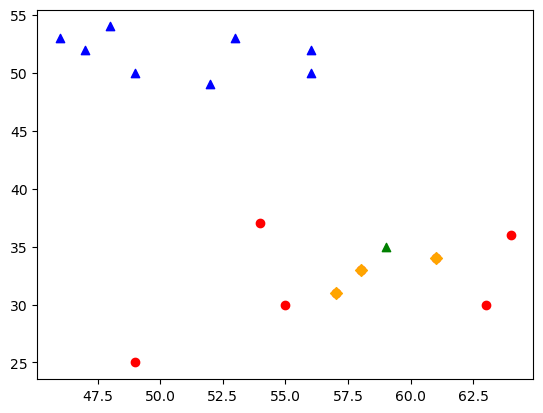

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 학습된 k-NN 분류기를 사용하여 새로운 데이터에 대해 예측을 수행하고,
# 해당 예측에 사용된 k개의 최근접 이웃을 시각화함으로써 모델의 분류 근거를 직관적으로 보여주는 실습임.
# 최근접 이웃들의 위치를 시각적으로 구분된 마커로 표현하여,
# 분류 결정이 어떻게 이루어졌는지를 설명하는 데 활용됨.
# ------------------------------------------------------------

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 새로운 데이터의 최근접 이웃 거리 및 인덱스 추출
# 2단계: 전체 개 데이터와 함께 시각화 설정
# 3단계: 최근접 이웃 데이터 포인트만 강조하여 표시
# 4단계: 예측 결과를 출력하여 최종 품종 확인
# ------------------------------------------------------------

# 새로운 데이터에 대해 학습된 모델이 선택한 k개의 최근접 이웃 정보를 반환
distances, indexes = knn.kneighbors(newdata)  
# distances: 새로운 데이터와 각 최근접 이웃 사이의 유클리드 거리 정보를 담은 배열
# indexes: dogs 배열에서 해당 이웃들이 위치한 행 인덱스를 담은 배열

# 주석 처리된 코드는 시각화 목적의 다른 형태 (D 마커 사용)를 시도한 흔적임
# plt.scatter(train_input[indexes], train_target[indexes], marker='D')

print('dist =', distances, 'indexes =', indexes, 'dogs[indexes]=', dogs[indexes])  
# 거리, 인덱스, 해당 위치의 실제 샘플 데이터를 함께 출력하여 이웃 정보 확인 가능
# dogs[indexes]: k개의 최근접 이웃들의 (길이, 높이) 정보 출력

# ------------------------------------------------------------
# [함수 정의] 최근접 이웃 포인트를 시각화하는 함수
# ------------------------------------------------------------

def draw_neighbor(data, index, k):  
    # k개의 최근접 이웃을 순회하며 시각적으로 표시하는 함수 정의
    for i in range(k):  
        plt.scatter(data[index][0][i][0], data[index][0][i][1], marker='D', color='orange')  
        # index는 2차원 배열 형태이므로 [0][i] 접근 필요
        # 각 이웃의 x좌표는 data[index][0][i][0], y좌표는 data[index][0][i][1]로 추출
        # 주황색 다이아몬드 마커로 이웃들을 강조하여 시각화함

# ------------------------------------------------------------
# [그래프 시각화 구성]
# ------------------------------------------------------------

plt.scatter(59, 35, color='green', marker='^')  
# 분류 대상이 되는 새로운 데이터를 초록색 삼각형 마커로 시각화

plt.scatter(dach_length, dach_height, c='red', label='Dachshund')  
# 닥스훈트 데이터를 빨간색 원으로 시각화하여 품종 구분

plt.scatter(jin_length, jin_height, c='blue', marker='^', label='Jindo dog')  
# 진돗개 데이터를 파란색 삼각형 마커로 시각화하여 품종 구분

draw_neighbor(dogs, indexes, k)  
# 주황색 다이아몬드 마커를 사용해 선택된 k개의 최근접 이웃을 시각적으로 강조함

print('data', newdata, ', classified as:', dog_classes[y_pred[0]])  
# 예측된 클래스(정수 라벨)를 dog_classes 딕셔너리를 통해 텍스트로 출력
# 시각화 결과와 함께 분류 결과를 사용자가 쉽게 확인할 수 있도록 출력


### Classifying iris using k-NN Classifier

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()
iris.data[:3]     # print the first three datasets

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2]])

In [10]:
print('iris data shape:', iris.data.shape)

iris data shape: (150, 4)


In [11]:
print('iris data features:', iris.feature_names)

iris data features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [12]:
print('iris data labels:', iris.target)

iris data labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


### Not necessary, but let's transform the data in to a Pandas DataFrame

In [13]:
import pandas as pd

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['target'] = pd.Series(iris.target)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [14]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [15]:
iris_df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [16]:
X = iris_df.iloc[:, :4]
y = iris_df.iloc[:, -1]

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

def iris_knn(X, y, k):
    X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=11)
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    return metrics.accuracy_score(y_test, y_pred)

k = 3
scores = iris_knn(X, y, k)
print('n_neighbors가 {0:d}일때 정확도: {1:.3f}'.format(k, scores))

n_neighbors가 3일때 정확도: 0.956


### Observe the accuracy for different k-values

In [18]:
for i in [1, 5, 10, 20, 30]:
    scores = iris_knn(X, y, i)
    print('n_neighbors가 {0:d}일때 정확도: {1:.3f}'.format(i, scores))

n_neighbors가 1일때 정확도: 0.933
n_neighbors가 5일때 정확도: 0.978
n_neighbors가 10일때 정확도: 0.956
n_neighbors가 20일때 정확도: 0.933
n_neighbors가 30일때 정확도: 0.911


### Apply the model to a new data for classification



In [19]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

k = 3
iris = load_iris()
knn = KNeighborsClassifier(n_neighbors = k)
knn.fit(iris.data, iris.target)

KNeighborsClassifier(n_neighbors=3)

In [20]:
classes = {0:'setosa', 1:'versicolor', 2:'virginica'}

# 새로운 데이터를 제시해 보자.
X = [[4, 2, 1.3, 0.4],
     [4, 3, 3.2, 2.2]]
y = knn.predict(X)

print('iris with the features {}: {}'.format(X[0], classes[y[0]]))
print('iris with the features {}: {}'.format(X[1], classes[y[1]]))

iris with the features [4, 2, 1.3, 0.4]: setosa
iris with the features [4, 3, 3.2, 2.2]: versicolor


In [21]:
y_pred_all = knn.predict(iris.data)
scores = metrics.accuracy_score(iris.target, y_pred_all)
print('accuracy with k = {0:d}: {1:.3f}'.format(k, scores))

accuracy with k = 3: 0.960


In [22]:
from sklearn.metrics import confusion_matrix
conf_result = confusion_matrix(iris.target,y_pred_all)
print(conf_result)

[[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]


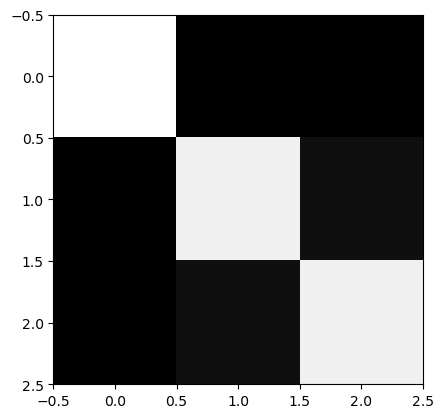

In [23]:
import matplotlib.pyplot as plt
plt.imshow(conf_result,cmap='grey')